In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def find_file(*filenames):
    for filename in filenames:
        for p in [Path(filename), Path.cwd()/filename, Path("/mnt/data")/filename]:
            if p.exists():
                return p
    raise FileNotFoundError(f"Could not find any of: {filenames}")

details_path = find_file("order_details.csv", "order_details(3).csv")
timestamps_path = find_file("order_timestamp.csv", "order_timestamp(3).csv")

details = pd.read_csv(details_path)
timestamps = pd.read_csv(timestamps_path)

print("order_details shape:", details.shape)
print("order_timestamp shape:", timestamps.shape)


order_details shape: (151803, 10)
order_timestamp shape: (151803, 4)


In [2]:
for col in ["start_time_slot", "accept_time", "arrived_pickup_at"]:
    timestamps[col] = pd.to_datetime(timestamps[col], errors="coerce")

df = details.merge(
    timestamps[["order_id", "start_time_slot", "accept_time", "arrived_pickup_at"]],
    on="order_id",
    how="left",
    validate="one_to_one"
)


df["acceptance_time_raw_min"] = (
    df["accept_time"] - df["start_time_slot"]
).dt.total_seconds() / 60
df["acceptance_time_min"] = df["acceptance_time_raw_min"].clip(lower=0)
df["AcceptanceTime10"] = np.where(
    df["acceptance_time_min"].notna(),
    (df["acceptance_time_min"] <= 10).astype(int),
    np.nan
)


df["arrival_time_raw_min"] = (
    df["arrived_pickup_at"] - df["accept_time"]
).dt.total_seconds() / 60
df["arrival_time_min"] = df["arrival_time_raw_min"].clip(lower=0)
df["ArrivalTime5"] = np.where(
    df["arrival_time_min"].notna(),
    (df["arrival_time_min"] <= 5).astype(int),
    np.nan
)


df["BATR_raw_min"] = (
    df["arrived_pickup_at"] - df["start_time_slot"]
).dt.total_seconds() / 60
df["BATR_min"] = df["BATR_raw_min"].clip(lower=0)
df["BATR15"] = np.where(
    df["BATR_min"].notna(),
    (df["BATR_min"] <= 15).astype(int),
    np.nan
)

valid = df[df["ArrivalTime5"].notna()].copy()
valid["ArrivalTime5"] = valid["ArrivalTime5"].astype(int)

print(f"Total orders: {len(df):,}")
print(f"Orders with valid ArrivalTime5: {len(valid):,}")
print(f"Missing/invalid ArrivalTime5: {df['ArrivalTime5'].isna().sum():,}")
print(f"Overall ArrivalTime5=1: {valid['ArrivalTime5'].mean()*100:.2f}%")

print()
display(
    valid["arrival_time_min"]
    .describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame("arrival_time_min")
)

print(f"Negative raw values for this component: {(df['arrival_time_raw_min'] < 0).sum():,}")
print(f"Negative raw BATR values set to zero: {(df['BATR_raw_min'] < 0).sum():,}")


Total orders: 151,803
Orders with valid ArrivalTime5: 151,579
Missing/invalid ArrivalTime5: 224
Overall ArrivalTime5=1: 66.89%



,arrival_time_min
count,"151,579.00"
mean,5.90
std,93.38
min,0.00
50%,4.00
75%,7.00
90%,11.00
95%,16.00
99%,33.00
max,"23,058.00"


Negative raw values for this component: 23,805
Negative raw BATR values set to zero: 23,805


In [3]:
city_counts = (
    valid.groupby(["order_city", "ArrivalTime5"])
         .size()
         .unstack(fill_value=0)
         .reindex(columns=[0, 1], fill_value=0)
)

city_pct = city_counts.div(city_counts.sum(axis=1), axis=0) * 100

city_summary = pd.DataFrame({
    "Orders": city_counts.sum(axis=1),
    "ArrivalTime5 = 0 (%)": city_pct[0],
    "ArrivalTime5 = 1 (%)": city_pct[1],
}).sort_index()

city_summary


,Orders,ArrivalTime5 = 0 (%),ArrivalTime5 = 1 (%)
order_city,,,
B,21324,22.03,77.97
K,78888,37.24,62.76
U,51367,31.37,68.63


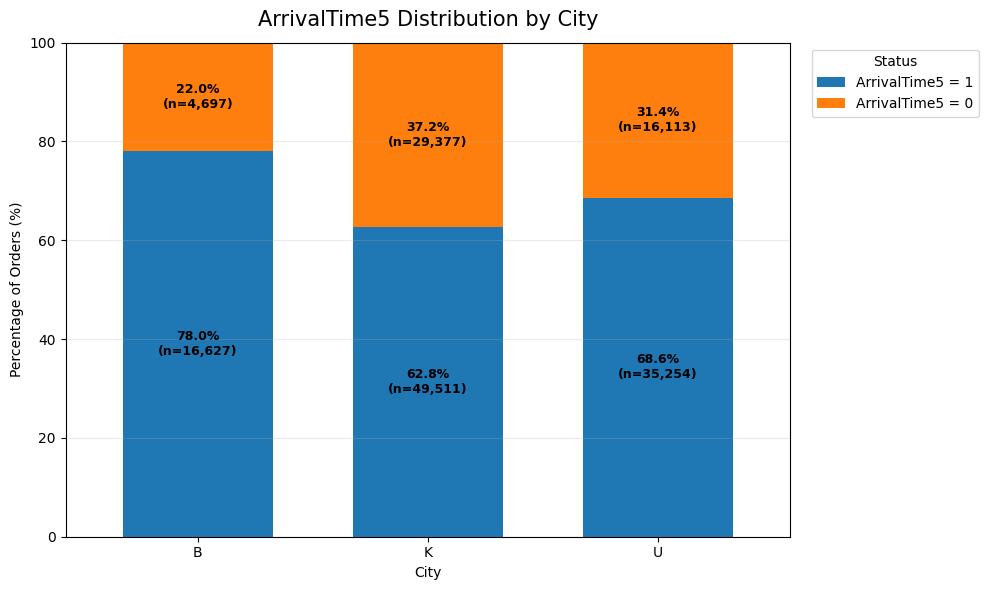

In [4]:
def add_stacked_percent_labels(ax, pct_df, count_df):
    for i, idx in enumerate(pct_df.index):
        bottom = 0
        for col in pct_df.columns:
            pct = float(pct_df.loc[idx, col])
            n = int(count_df.loc[idx, col])
            ax.text(
                i,
                bottom + pct/2,
                f"{pct:.1f}%\n(n={n:,})",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold"
            )
            bottom += pct

plot_df = city_pct[[1, 0]].copy()
plot_counts = city_counts[[1, 0]].copy()

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    width=0.65
)

add_stacked_percent_labels(ax, plot_df, plot_counts)

ax.set_title("ArrivalTime5 Distribution by City", fontsize=15, pad=12)
ax.set_xlabel("City")
ax.set_ylabel("Percentage of Orders (%)")
ax.set_ylim(0, 100)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(
    ["ArrivalTime5 = 1", "ArrivalTime5 = 0"],
    title="Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [5]:
district_counts = (
    valid.groupby(["order_city", "district", "ArrivalTime5"])
         .size()
         .unstack(fill_value=0)
         .reindex(columns=[0, 1], fill_value=0)
)

district_pct = district_counts.div(district_counts.sum(axis=1), axis=0) * 100

district_summary = district_counts.copy()
district_summary.columns = ["ArrivalTime5_0_Count", "ArrivalTime5_1_Count"]
district_summary["Orders"] = district_summary.sum(axis=1)
district_summary["ArrivalTime5 = 0 (%)"] = district_pct[0]
district_summary["ArrivalTime5 = 1 (%)"] = district_pct[1]

district_summary = district_summary[
    ["Orders", "ArrivalTime5_0_Count", "ArrivalTime5_1_Count",
     "ArrivalTime5 = 0 (%)", "ArrivalTime5 = 1 (%)"]
]

district_summary


Orders  ArrivalTime5_0_Count  ArrivalTime5_1_Count  \
order_city district                                                       
B          3720        9460                  1579                  7881   
           3724        3452                   559                  2893   
           3728        1623                   521                  1102   
           3732        2181                   468                  1713   
           3740        4543                  1558                  2985   
           3752          65                    12                    53   
K          1468        3989                  1326                  2663   
           1472          25                    16                     9   
           1476        3259                  1256                  2003   
           1480       26893                  9800                 17093   
           1484        5410                  2136                  3274   
           1488          79                    46                    33   
           1492          30                    12                    18   
           1496        1327                   509                   818   
           1508        8887                  2764                  6123   
           1512       10864                  4157                  6707   
           1520         222                   110                   112   
           1528        7115                  2769                  4346   
           4176        4216                  2016                  2200   
           4532        4797                  1672                  3125   
           4732        1775                   788                   987   
U          1392           5                     4                     1   
           1396        3469                  1180                  2289   
           1400        4162                  1445                  2717   
           1404        4016                  1194                  2822   
           1408        2823                  1012                  1811   
           1412          10                     6                     4   
           1416        3149                  1236                  1913   
           1420       12031                  2903                  9128   
           1424          14                     8                     6   
           1428        8575                  3142                  5433   
           1432       13113                  3983                  9130   

                     ArrivalTime5 = 0 (%)  ArrivalTime5 = 1 (%)  
order_city district                                              
B          3720                     16.69                 83.31  
           3724                     16.19                 83.81  
           3728                     32.10                 67.90  
           3732                     21.46                 78.54  
           3740                     34.29                 65.71  
           3752                     18.46                 81.54  
K          1468                     33.24                 66.76  
           1472                     64.00                 36.00  
           1476                     38.54                 61.46  
           1480                     36.44                 63.56  
           1484                     39.48                 60.52  
           1488                     58.23                 41.77  
           1492                     40.00                 60.00  
           1496                     38.36                 61.64  
           1508                     31.10                 68.90  
           1512                     38.26                 61.74  
           1520                     49.55                 50.45  
           1528                     38.92                 61.08  
           4176                     47.82                 52.18  
           4532                     34.86                 65.14  
           4732   


CITY B


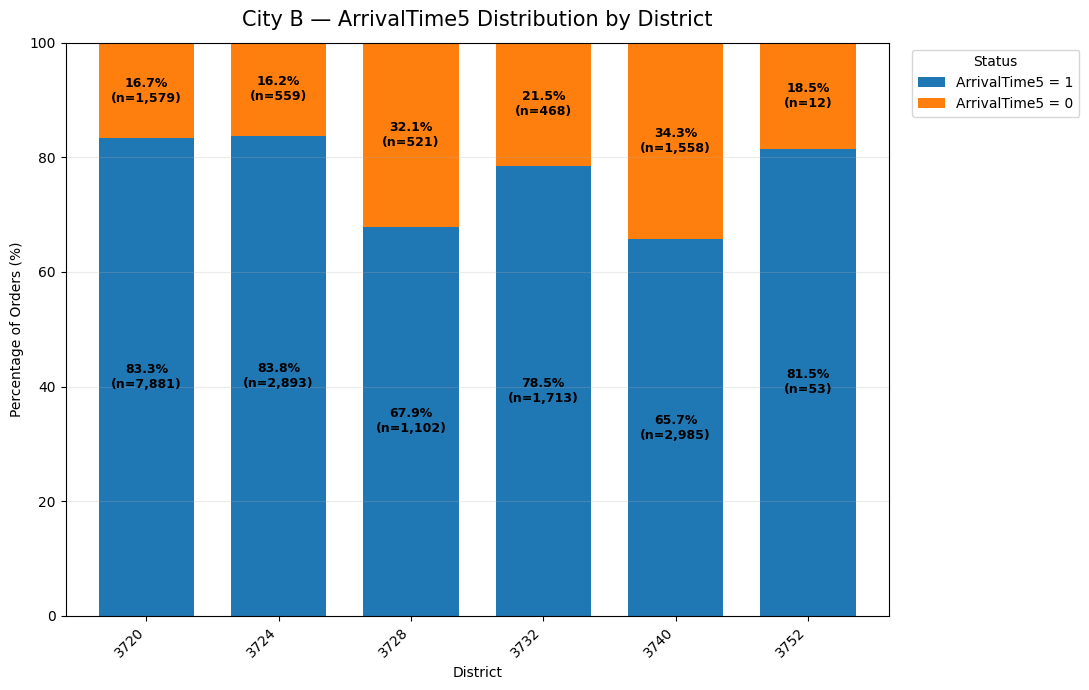

,Orders,ArrivalTime5_0_Count,ArrivalTime5_1_Count,ArrivalTime5 = 0 (%),ArrivalTime5 = 1 (%)
district,,,,,
3720,9460,1579,7881,16.69,83.31
3724,3452,559,2893,16.19,83.81
3728,1623,521,1102,32.10,67.90
3732,2181,468,1713,21.46,78.54
3740,4543,1558,2985,34.29,65.71
3752,65,12,53,18.46,81.54



CITY K


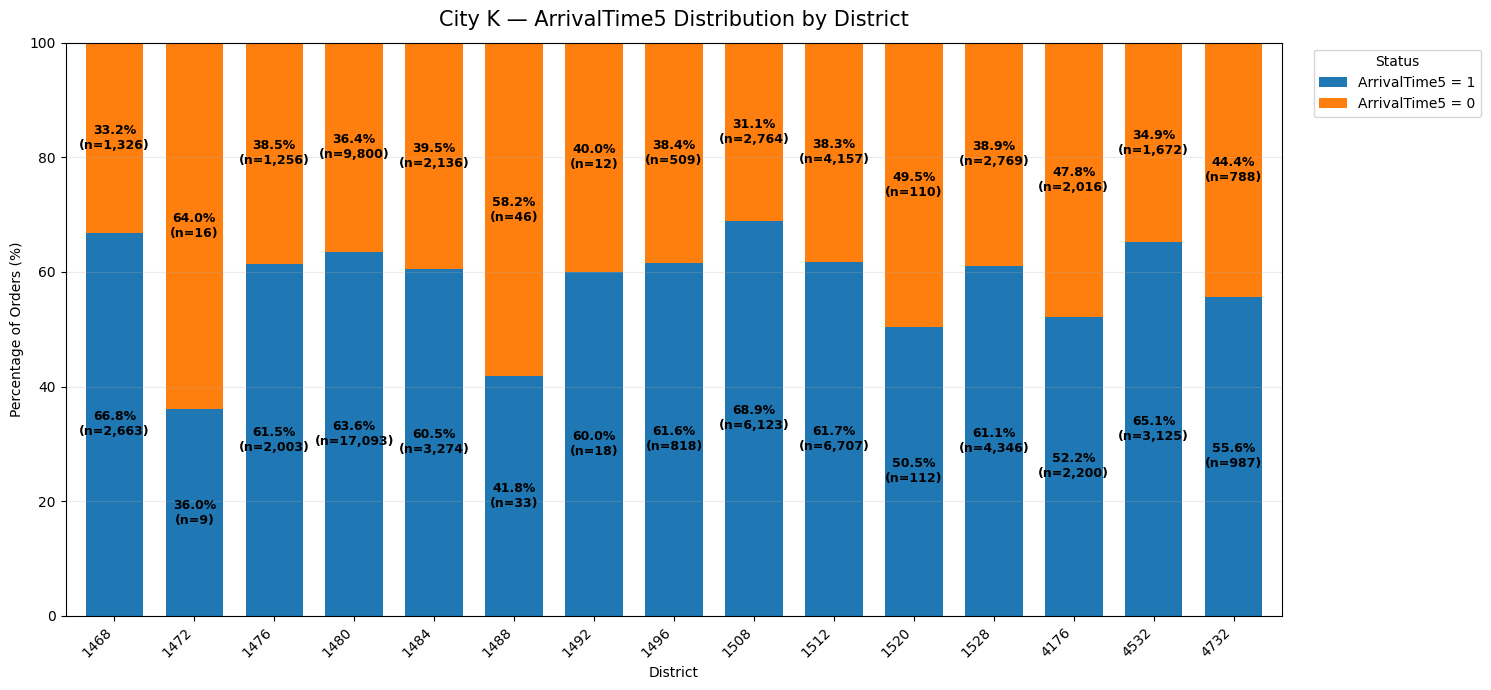

,Orders,ArrivalTime5_0_Count,ArrivalTime5_1_Count,ArrivalTime5 = 0 (%),ArrivalTime5 = 1 (%)
district,,,,,
1468,3989,1326,2663,33.24,66.76
1472,25,16,9,64.00,36.00
1476,3259,1256,2003,38.54,61.46
1480,26893,9800,17093,36.44,63.56
1484,5410,2136,3274,39.48,60.52
1488,79,46,33,58.23,41.77
1492,30,12,18,40.00,60.00
1496,1327,509,818,38.36,61.64
1508,8887,2764,6123,31.10,68.90



CITY U


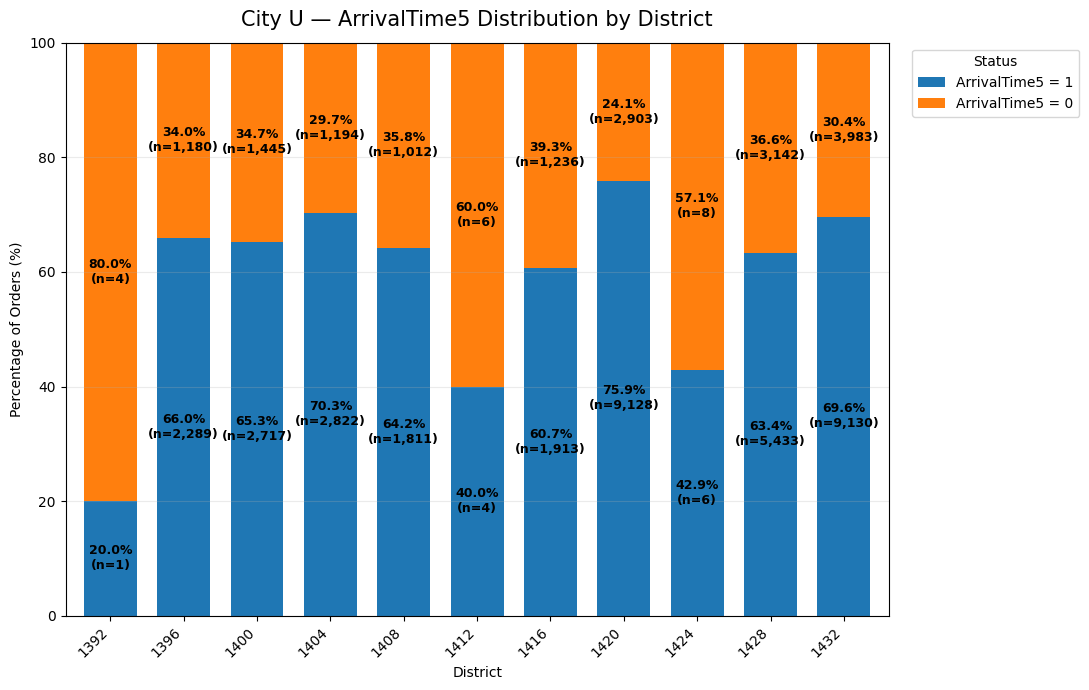

,Orders,ArrivalTime5_0_Count,ArrivalTime5_1_Count,ArrivalTime5 = 0 (%),ArrivalTime5 = 1 (%)
district,,,,,
1392,5,4,1,80.00,20.00
1396,3469,1180,2289,34.02,65.98
1400,4162,1445,2717,34.72,65.28
1404,4016,1194,2822,29.73,70.27
1408,2823,1012,1811,35.85,64.15
1412,10,6,4,60.00,40.00
1416,3149,1236,1913,39.25,60.75
1420,12031,2903,9128,24.13,75.87
1424,14,8,6,57.14,42.86


In [6]:
def plot_city_district_arrival5(city):
    sub_counts = district_counts.loc[city].copy().sort_index()
    sub_pct = sub_counts.div(sub_counts.sum(axis=1), axis=0) * 100

    plot_df = sub_pct[[1, 0]].copy()
    plot_counts = sub_counts[[1, 0]].copy()

    plot_df.index = plot_df.index.astype(str)
    plot_counts.index = plot_counts.index.astype(str)

    fig_width = max(11, len(plot_df) * 1.0)

    ax = plot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(fig_width, 7),
        width=0.72
    )

    add_stacked_percent_labels(ax, plot_df, plot_counts)

    ax.set_title(f"City {city} — ArrivalTime5 Distribution by District", fontsize=15, pad=12)
    ax.set_xlabel("District")
    ax.set_ylabel("Percentage of Orders (%)")
    ax.set_ylim(0, 100)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(
        ["ArrivalTime5 = 1", "ArrivalTime5 = 0"],
        title="Status",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    return district_summary.loc[city].copy().sort_index()

for city in ["B", "K", "U"]:
    print("\n" + "=" * 80)
    print(f"CITY {city}")
    print("=" * 80)
    display(plot_city_district_arrival5(city))


In [7]:
ranking = (
    district_summary
    .reset_index()
    .sort_values(
        ["order_city", "ArrivalTime5 = 1 (%)"],
        ascending=[True, False]
    )
    .copy()
)

ranking["Rank within City"] = (
    ranking.groupby("order_city")["ArrivalTime5 = 1 (%)"]
           .rank(method="first", ascending=False)
           .astype(int)
)

ranking = ranking[
    [
        "order_city",
        "Rank within City",
        "district",
        "Orders",
        "ArrivalTime5_1_Count",
        "ArrivalTime5_0_Count",
        "ArrivalTime5 = 1 (%)",
        "ArrivalTime5 = 0 (%)"
    ]
]

ranking


,order_city,Rank within City,district,Orders,ArrivalTime5_1_Count,ArrivalTime5_0_Count,ArrivalTime5 = 1 (%),ArrivalTime5 = 0 (%)
1,B,1,3724,3452,2893,559,83.81,16.19
0,B,2,3720,9460,7881,1579,83.31,16.69
5,B,3,3752,65,53,12,81.54,18.46
3,B,4,3732,2181,1713,468,78.54,21.46
2,B,5,3728,1623,1102,521,67.90,32.10
4,B,6,3740,4543,2985,1558,65.71,34.29
14,K,1,1508,8887,6123,2764,68.90,31.10
6,K,2,1468,3989,2663,1326,66.76,33.24
19,K,3,4532,4797,3125,1672,65.14,34.86
9,K,4,1480,26893,17093,9800,63.56,36.44


,order_city,ArrivalTime5,Orders,BATR_Mean,BATR_Median,BATR_P90,BATR15 Success (%)
0,B,0,4697,16.14,11.00,26.00,68.28
1,B,1,16627,2.62,0.00,6.00,96.54
2,K,0,29377,22.17,17.00,34.00,44.23
3,K,1,49511,6.11,3.00,16.00,89.16
4,U,0,16113,19.50,15.00,32.00,53.09
5,U,1,35254,5.18,3.00,14.00,92.05


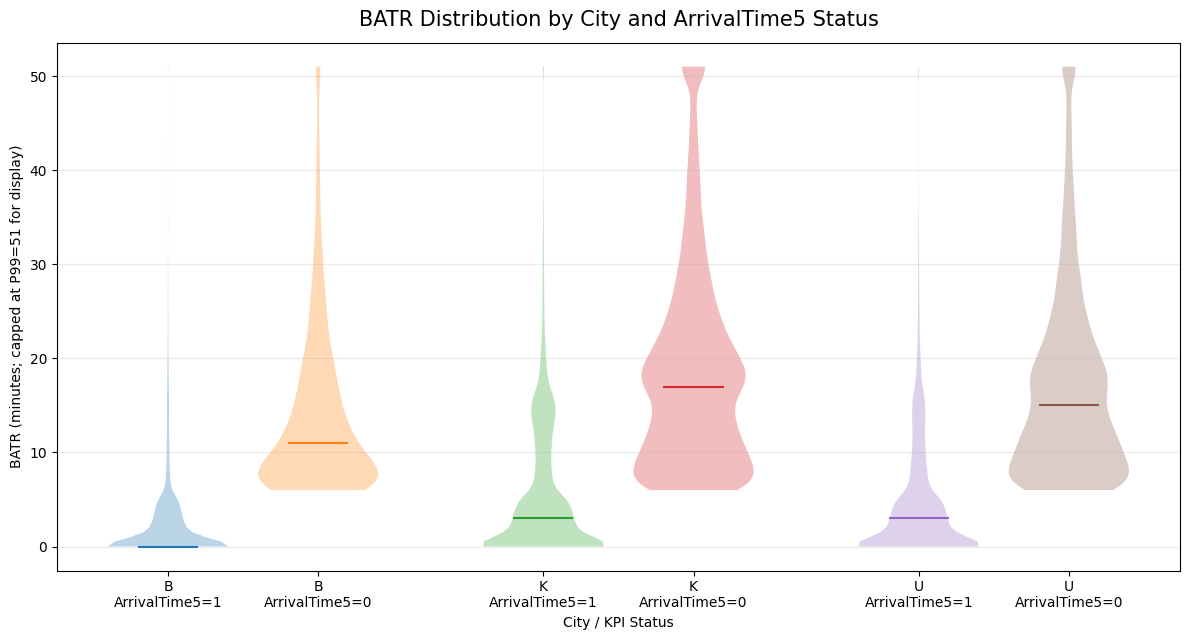

In [8]:
batr_diag = valid[valid["BATR_min"].notna()].copy()

BATR_P99 = batr_diag["BATR_min"].quantile(0.99)
batr_diag["BATR_plot_min"] = batr_diag["BATR_min"].clip(upper=BATR_P99)

city_batr_summary = (
    batr_diag.groupby(["order_city", "ArrivalTime5"])
             .agg(
                 Orders=("order_id", "count"),
                 BATR_Mean=("BATR_min", "mean"),
                 BATR_Median=("BATR_min", "median"),
                 BATR_P90=("BATR_min", lambda s: s.quantile(0.90)),
                 BATR15_Success=("BATR15", "mean")
             )
             .reset_index()
)

city_batr_summary["BATR15 Success (%)"] = city_batr_summary["BATR15_Success"] * 100

display(city_batr_summary[
    ["order_city", "ArrivalTime5", "Orders",
     "BATR_Mean", "BATR_Median", "BATR_P90", "BATR15 Success (%)"]
])

fig, ax = plt.subplots(figsize=(12, 6.5))

positions, labels = [], []
pos = 1

for city in ["B", "K", "U"]:
    for status in [1, 0]:
        vals = batr_diag.loc[
            (batr_diag["order_city"] == city) &
            (batr_diag["ArrivalTime5"] == status),
            "BATR_plot_min"
        ].dropna().values

        if len(vals) >= 2 and np.nanstd(vals) > 0:
            ax.violinplot(
                vals,
                positions=[pos],
                widths=0.8,
                showmeans=False,
                showmedians=True,
                showextrema=False
            )
        elif len(vals) >= 1:
            ax.scatter([pos], [np.nanmedian(vals)])

        positions.append(pos)
        labels.append(f"{city}\nArrivalTime5={status}")
        pos += 1
    pos += 0.5

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_title("BATR Distribution by City and ArrivalTime5 Status", fontsize=15, pad=12)
ax.set_xlabel("City / KPI Status")
ax.set_ylabel(f"BATR (minutes; capped at P99={BATR_P99:.0f} for display)")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()



CITY B — BATR VIOLIN DIAGNOSTIC


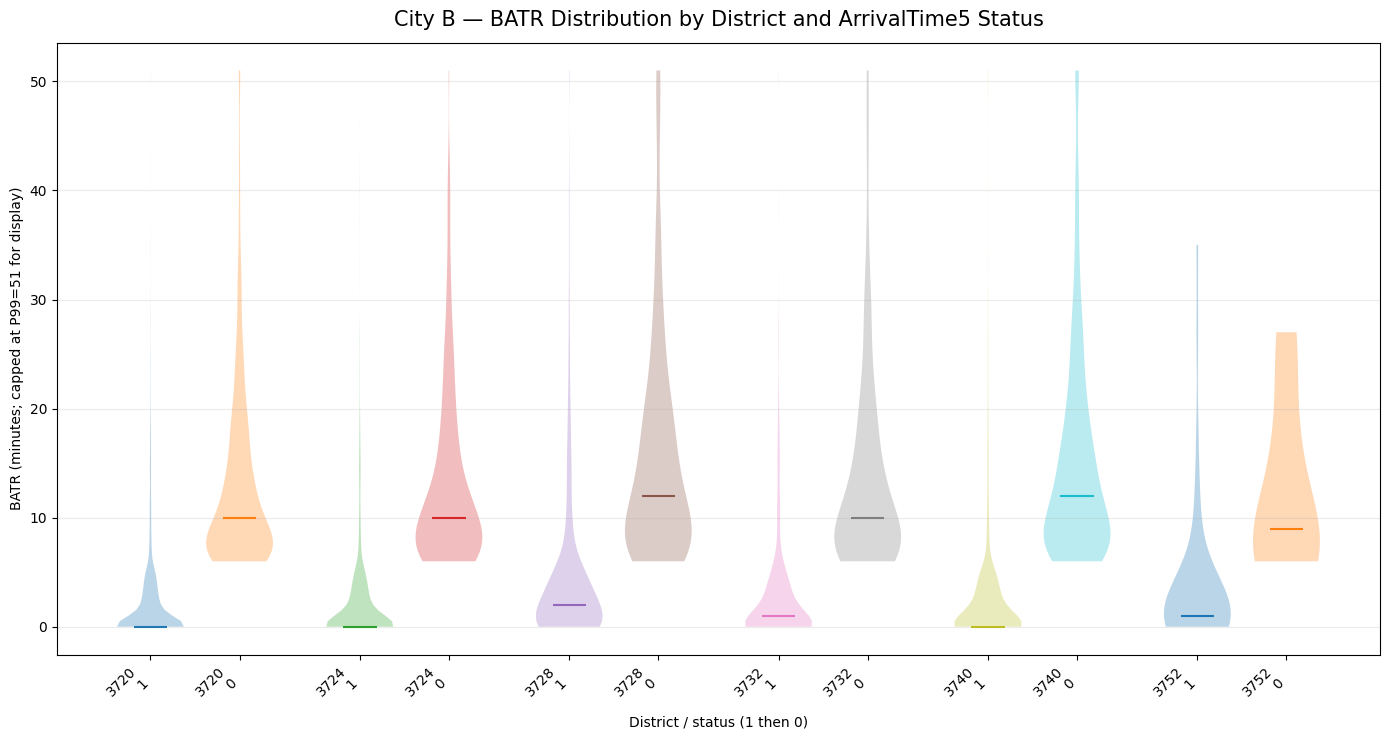

,order_city,district,ArrivalTime5,Orders,BATR_Mean,BATR_Median,BATR_P90,BATR15 Success (%)
1,B,3720,1,7881,2.34,0.00,6.00,96.99
0,B,3720,0,1579,14.03,10.00,24.00,72.58
3,B,3724,1,2893,2.24,0.00,5.00,97.23
2,B,3724,0,559,13.24,10.00,25.00,72.45
5,B,3728,1,1102,4.52,2.00,13.00,92.74
4,B,3728,0,521,18.44,12.00,30.00,62.00
7,B,3732,1,1713,2.87,1.00,7.00,96.03
6,B,3732,0,468,14.07,10.00,26.30,71.37
9,B,3740,1,2985,2.88,0.00,5.00,96.42
8,B,3740,0,1558,19.19,12.00,29.00,63.61



CITY K — BATR VIOLIN DIAGNOSTIC


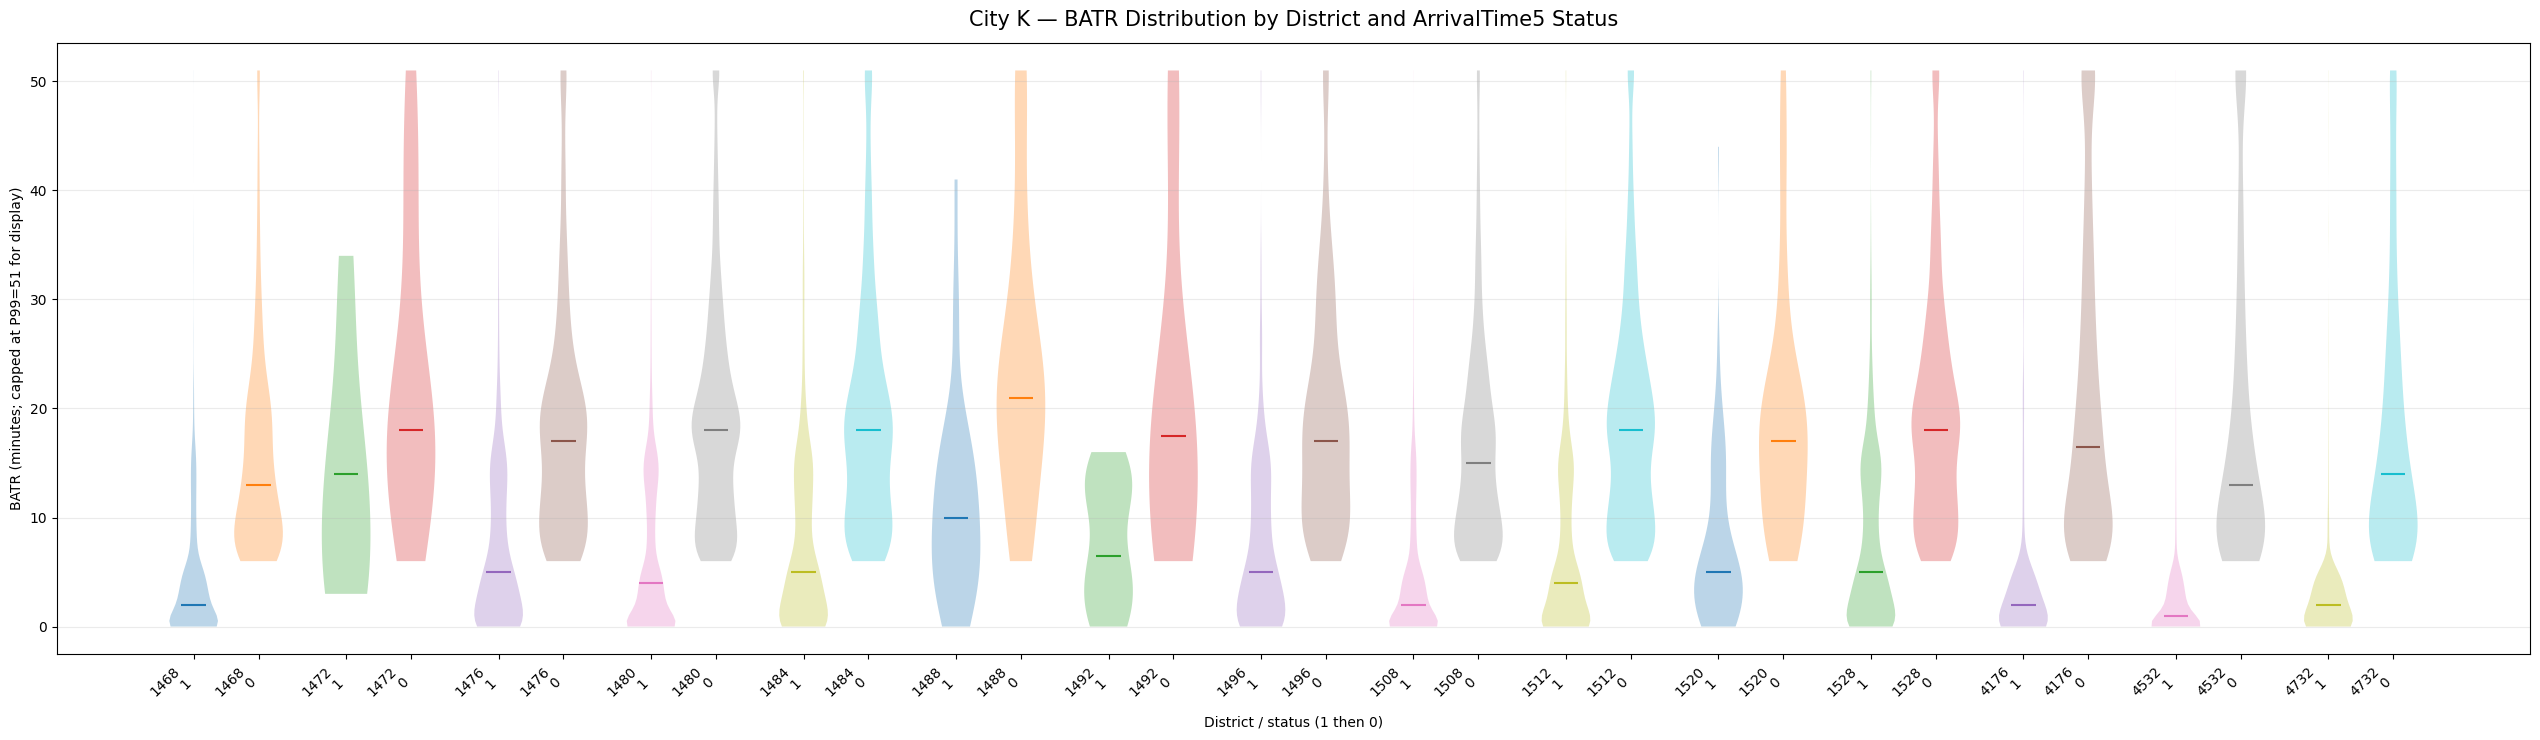

,order_city,district,ArrivalTime5,Orders,BATR_Mean,BATR_Median,BATR_P90,BATR15 Success (%)
13,K,1468,1,2663,4.19,2.00,12.00,95.23
12,K,1468,0,1326,15.98,13.00,28.00,58.90
15,K,1472,1,9,13.44,14.00,27.60,66.67
14,K,1472,0,16,22.81,18.00,42.50,25.00
17,K,1476,1,2003,7.01,5.00,16.00,87.72
16,K,1476,0,1256,38.26,17.00,32.50,45.38
19,K,1480,1,17093,6.75,4.00,16.00,87.63
18,K,1480,0,9800,23.13,18.00,33.00,39.76
21,K,1484,1,3274,7.86,5.00,17.00,84.94
20,K,1484,0,2136,20.22,18.00,35.00,41.15



CITY U — BATR VIOLIN DIAGNOSTIC


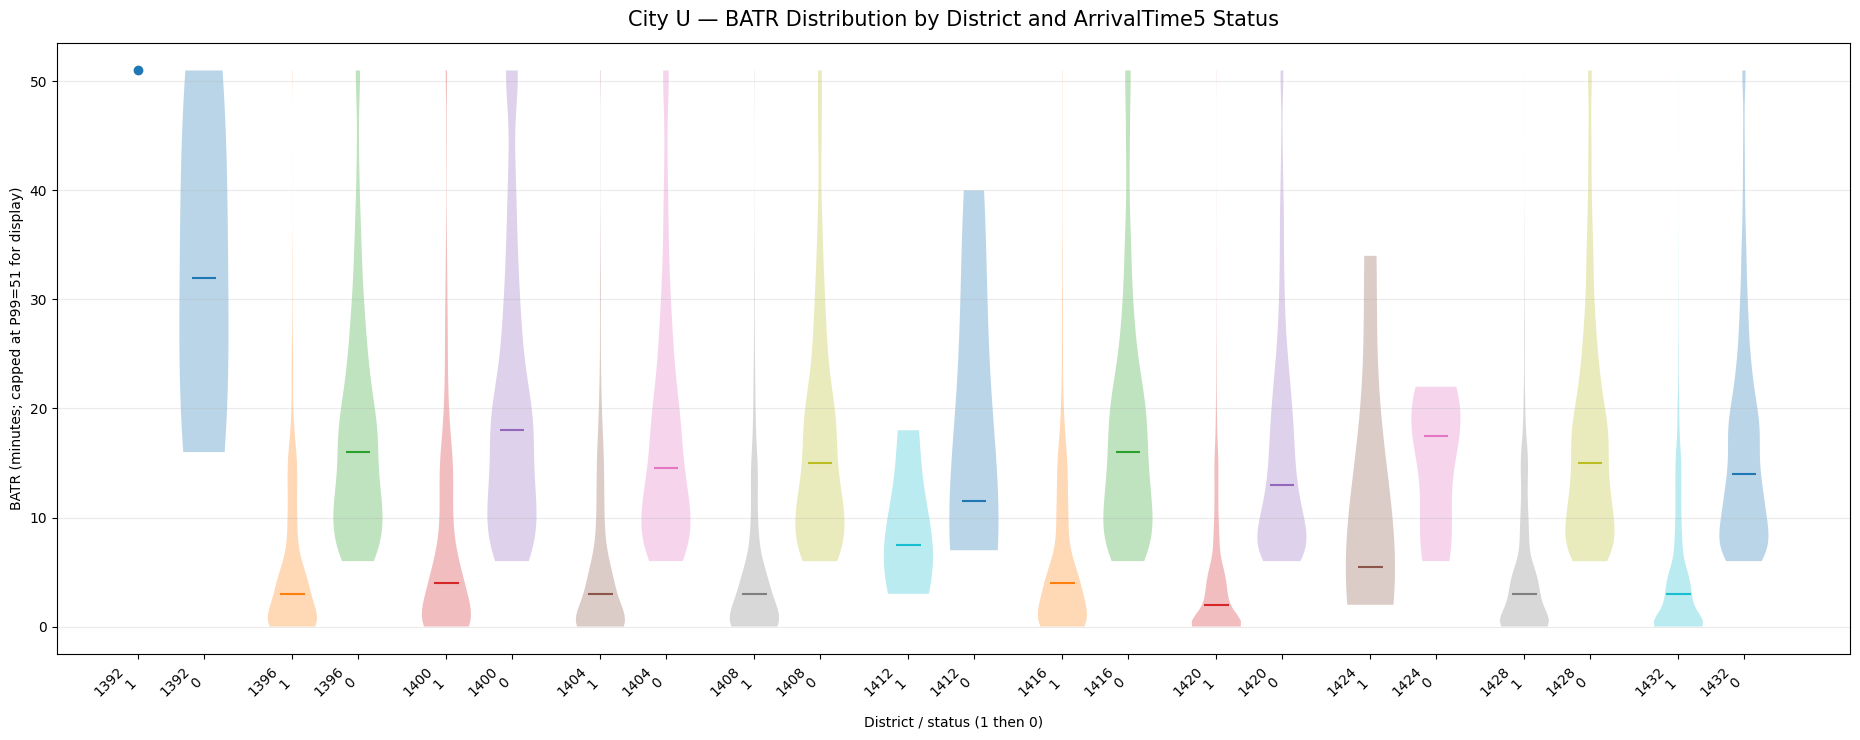

,order_city,district,ArrivalTime5,Orders,BATR_Mean,BATR_Median,BATR_P90,BATR15 Success (%)
43,U,1392,1,1,57.00,57.00,57.00,0.00
42,U,1392,0,4,35.00,32.00,54.00,0.00
45,U,1396,1,2289,5.65,3.00,15.00,91.48
44,U,1396,0,1180,18.18,16.00,32.00,48.98
47,U,1400,1,2717,8.25,4.00,19.00,84.50
46,U,1400,0,1445,25.59,18.00,41.00,42.21
49,U,1404,1,2822,5.64,3.00,16.00,89.48
48,U,1404,0,1194,20.54,14.50,34.00,53.43
51,U,1408,1,1811,5.15,3.00,14.00,92.10
50,U,1408,0,1012,17.89,15.00,31.00,52.87


In [9]:
district_batr_summary = (
    batr_diag.groupby(["order_city", "district", "ArrivalTime5"])
             .agg(
                 Orders=("order_id", "count"),
                 BATR_Mean=("BATR_min", "mean"),
                 BATR_Median=("BATR_min", "median"),
                 BATR_P90=("BATR_min", lambda s: s.quantile(0.90)),
                 BATR15_Success=("BATR15", "mean")
             )
             .reset_index()
)

district_batr_summary["BATR15 Success (%)"] = district_batr_summary["BATR15_Success"] * 100

def plot_district_batr_violins(city):
    city_data = batr_diag[batr_diag["order_city"] == city].copy()
    districts = sorted(city_data["district"].dropna().unique())

    fig_width = max(14, len(districts) * 1.7)
    fig, ax = plt.subplots(figsize=(fig_width, 7.5))

    positions, labels = [], []
    pos = 1

    for district in districts:
        for status in [1, 0]:
            vals = city_data.loc[
                (city_data["district"] == district) &
                (city_data["ArrivalTime5"] == status),
                "BATR_plot_min"
            ].dropna().values

            if len(vals) >= 2 and np.nanstd(vals) > 0:
                ax.violinplot(
                    vals,
                    positions=[pos],
                    widths=0.75,
                    showmeans=False,
                    showmedians=True,
                    showextrema=False
                )
            elif len(vals) >= 1:
                ax.scatter([pos], [np.nanmedian(vals)])

            positions.append(pos)
            labels.append(f"{int(district)}\n{status}")
            pos += 1
        pos += 0.35

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_title(
        f"City {city} — BATR Distribution by District and ArrivalTime5 Status",
        fontsize=15,
        pad=12
    )
    ax.set_xlabel("District / status (1 then 0)")
    ax.set_ylabel(f"BATR (minutes; capped at P99={BATR_P99:.0f} for display)")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    return (
        district_batr_summary[
            district_batr_summary["order_city"] == city
        ]
        .sort_values(["district", "ArrivalTime5"], ascending=[True, False])
        [["order_city", "district", "ArrivalTime5", "Orders",
          "BATR_Mean", "BATR_Median", "BATR_P90", "BATR15 Success (%)"]]
    )

for city in ["B", "K", "U"]:
    print("\n" + "=" * 80)
    print(f"CITY {city} — BATR VIOLIN DIAGNOSTIC")
    print("=" * 80)
    display(plot_district_batr_violins(city))


In [10]:
component_valid = df[
    df["BATR15"].notna()
    & df["AcceptanceTime10"].notna()
    & df["ArrivalTime5"].notna()
].copy()

component_valid["BATR15"] = component_valid["BATR15"].astype(int)
component_valid["AcceptanceTime10"] = component_valid["AcceptanceTime10"].astype(int)
component_valid["ArrivalTime5"] = component_valid["ArrivalTime5"].astype(int)

late = component_valid[component_valid["BATR15"] == 0].copy()

late["Failure_Source"] = np.select(
    [
        (late["AcceptanceTime10"] == 0) & (late["ArrivalTime5"] == 1),
        (late["AcceptanceTime10"] == 1) & (late["ArrivalTime5"] == 0),
        (late["AcceptanceTime10"] == 0) & (late["ArrivalTime5"] == 0),
    ],
    [
        "Acceptance only",
        "Arrival only",
        "Both"
    ],
    default="Neither"
)

source_order = ["Acceptance only", "Arrival only", "Both", "Neither"]

overall_failure = (
    late["Failure_Source"]
    .value_counts()
    .reindex(source_order, fill_value=0)
    .rename("Late Orders")
    .to_frame()
)
overall_failure["Share of BATR15 failures (%)"] = (
    overall_failure["Late Orders"] / overall_failure["Late Orders"].sum() * 100
)

print("OVERALL LATE-BATR DECOMPOSITION")
display(overall_failure)

city_failure_counts = (
    late.groupby(["order_city", "Failure_Source"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=source_order, fill_value=0)
)
city_failure_pct = city_failure_counts.div(city_failure_counts.sum(axis=1), axis=0) * 100

print("LATE-BATR DECOMPOSITION BY CITY — % OF BATR15 FAILURES")
display(city_failure_pct)

district_failure_counts = (
    late.groupby(["order_city", "district", "Failure_Source"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=source_order, fill_value=0)
)
district_failure_pct = district_failure_counts.div(
    district_failure_counts.sum(axis=1), axis=0
) * 100

print("LATE-BATR DECOMPOSITION BY CITY / DISTRICT — % OF BATR15 FAILURES")
display(district_failure_pct)


OVERALL LATE-BATR DECOMPOSITION


,Late Orders,Share of BATR15 failures (%)
Failure_Source,,
Acceptance only,8744,25.58
Arrival only,9455,27.66
Both,15978,46.75
Neither,0,0.00


LATE-BATR DECOMPOSITION BY CITY — % OF BATR15 FAILURES


Failure_Source,Acceptance only,Arrival only,Both,Neither
order_city,,,,
B,27.85,42.03,30.12,0.00
K,24.68,26.61,48.71,0.00
U,27.04,27.01,45.95,0.00


LATE-BATR DECOMPOSITION BY CITY / DISTRICT — % OF BATR15 FAILURES


Failure_Source       Acceptance only  Arrival only  Both  Neither
order_city district                                              
B          3720                35.37         35.82 28.81     0.00
           3724                34.19         34.19 31.62     0.00
           3728                28.78         32.01 39.21     0.00
           3732                33.66         30.20 36.14     0.00
           3740                15.88         58.75 25.37     0.00
           3752                42.86         28.57 28.57     0.00
K          1468                18.90         37.50 43.60     0.00
           1472                20.00         26.67 53.33     0.00
           1476                26.39         19.10 54.51     0.00
           1480                26.37         20.24 53.39     0.00
           1484                28.17         21.43 50.40     0.00
           1488                18.60         11.63 69.77     0.00
           1492                12.50          0.00 87.50     0.00
           1496                25.50         20.25 54.25     0.00
           1508                23.52         32.12 44.35     0.00
           1512                27.06         18.92 54.02     0.00
           1520                21.18         21.18 57.65     0.00
           1528                29.72         15.64 54.64     0.00
           4176                10.95         65.37 23.67     0.00
           4532                10.07         77.24 12.69     0.00
           4732                 5.66         79.78 14.56     0.00
U          1392                20.00         20.00 60.00     0.00
           1396                24.47         21.96 53.58     0.00
           1400                33.52         17.52 48.96     0.00
           1404                34.82         23.09 42.09     0.00
           1408                23.06         31.45 45.48     0.00
           1412                25.00         25.00 50.00     0.00
           1416                22.97         28.26 48.77     0.00
           1420                30.50         27.72 41.78     0.00
           1424                16.67         16.67 66.67     0.00
           1428                22.21         31.98 45.81     0.00
           1432                25.65         29.02 45.32     0.00